# Bloco 01 de exercícios


## Exercício 1 -- Derivação numérica

Considere a função:

$$
f(x)=x^3-2x^2+x
$$

A derivada exata em $x=2$ é:

$$
f'(x)=3x^2-4x+1
\qquad\Rightarrow\qquad
f'(2)=5
$$

Para \(h=0{,}1\), utilizamos:

$$
f'_{\text{prog}}(x)\approx\frac{f(x+h)-f(x)}{h}
$$

$$
f'_{\text{regr}}(x)\approx\frac{f(x)-f(x-h)}{h}
$$

$$
f'_{\text{central}}(x)\approx\frac{f(x+h)-f(x-h)}{2h}
$$

O erro relativo percentual é calculado por:

$$
E_r(\%)=
\left|
\frac{f'(x)-f'_{\text{aprox}}(x)}
{f'(x)}
\right|100
$$

A aproximação com menor \(E_r\) apresenta maior precisão.

In [3]:
def f(x): 
    return x**3 - 2*x**2 + x                # Define a função

x = 2                                             # Define o ponto de avaliação
h = 0.1  # Define o passo

df_exata = 3*x**2 - 4*x + 1  # Calcula a derivada exata
df_prog = (f(x + h) - f(x)) / h  # Calcula a diferença progressiva
df_regr = (f(x) - f(x - h)) / h  # Calcula a diferença regressiva
df_central = (f(x + h) - f(x - h)) / (2*h)  # Calcula a diferença central

er_prog = abs((df_exata - df_prog) / df_exata) * 100  # Calcula o erro da progressiva
er_regr = abs((df_exata - df_regr) / df_exata) * 100  # Calcula o erro da regressiva
er_central = abs((df_exata - df_central) / df_exata) * 100  # Calcula o erro da central

# Organiza os resultados
resultados = {"Progressiva": (df_prog, er_prog), 
              "Regressiva": (df_regr, er_regr), 
              "Central": (df_central, er_central)}  
print(f"{'Método':<12} {'f\'(2)':>10} {'Er (%)':>10}")  # Exibe o cabeçalho
for metodo, (aprox, erro) in resultados.items(): 
    print(f"{metodo:<12} {aprox:>10.4f} {erro:>10.2f}")  # Exibe os resultados

Método            f'(2)     Er (%)
Progressiva      5.4100       8.20
Regressiva       4.6100       7.80
Central          5.0100       0.20


## Exercícios 2 e 3 — Influência de $h$ na diferenciação numérica

Considere:

$$
f(x)=x^3
$$

A derivada exata é:

$$
f'(x)=3x^2
$$

Logo, em $x=3$:

$$
f'(3)=27
$$

Na diferença central:

$$
f'(x)\approx\frac{f(x+h)-f(x-h)}{2h}
$$

O erro relativo percentual é:

$$
E_r(\%)=
\left|
\frac{f'(3)-f'_{\mathrm{aprox}}(3)}
{f'(3)}
\right|100
$$

Serão avaliados diferentes valores de $h$ para observar a influência do espaçamento na precisão.

Para a análise gráfica, deve-se representar $E_r$ em função de $h$ em escala logarítmica.

A hipótese esperada é que, para este caso, a redução de $h$ diminua o erro de truncamento. Entretanto, em problemas computacionais gerais, valores excessivamente pequenos de $h$ podem aumentar o erro de arredondamento.

       h      f_aprox       Er (%)
    0.50    27.250000     0.925926
    0.25    27.062500     0.231481
    0.10    27.010000     0.037037
    0.01    27.000100     0.000370


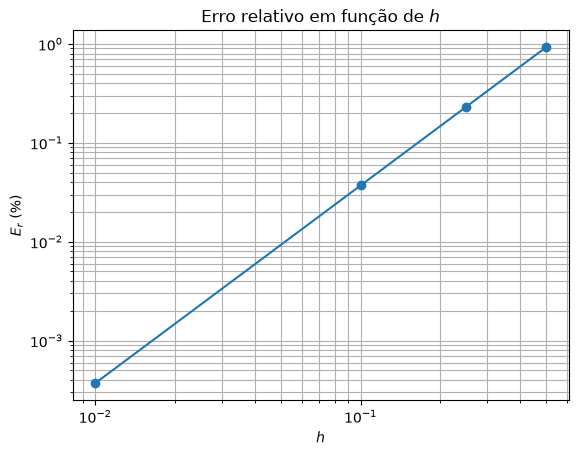

In [4]:
import numpy as np                                      # Importa a biblioteca numérica
import matplotlib.pyplot as plt                        # Importa a biblioteca gráfica

def f(x): return x**3                                   # Define a função
    
x = 3                                                   # Define o ponto de avaliação
h = np.array([0.5, 0.25, 0.1, 0.01])                  # Define os valores de h
df_exata = 27                                           # Define a derivada exata
df_aprox = (f(x + h) - f(x - h)) / (2*h)              # Calcula a diferença central
erro = np.abs((df_exata - df_aprox) / df_exata) * 100 # Calcula o erro relativo percentual
print(f"{'h':>8} {'f_aprox':>12} {'Er (%)':>12}")       # Exibe o cabeçalho

for i in range(len(h)): 
    print(f"{h[i]:8.2f} {df_aprox[i]:12.6f} {erro[i]:12.6f}") # Exibe os resultados
plt.loglog(h, erro, 'o-')                               # Plota o erro em escala log-log
plt.xlabel('$h$')                                      # Define o eixo horizontal
plt.ylabel('$E_r$ (%)')                                # Define o eixo vertical
plt.title('Erro relativo em função de $h$')             # Define o título
plt.grid(True, which='both')                            # Adiciona a grade
plt.show()                                              # Exibe o gráfico

## Exercícios 4 e 5 — Diferenciação de dados experimentais

Considere os dados experimentais $x$ e $y$, sem assumir uma expressão analítica para $y=f(x)$.

Para pontos internos, utiliza-se a diferença central:

$$
\frac{dy}{dx}\approx\frac{y_{i+1}-y_{i-1}}{x_{i+1}-x_{i-1}}
$$

No primeiro ponto, utiliza-se a diferença progressiva:

$$
\frac{dy}{dx}\approx\frac{y_1-y_0}{x_1-x_0}
$$

No último ponto, utiliza-se a diferença regressiva:

$$
\frac{dy}{dx}\approx\frac{y_n-y_{n-1}}{x_n-x_{n-1}}
$$

As derivadas são organizadas em um vetor e representadas graficamente junto aos dados experimentais.

O maior valor de $\frac{dy}{dx}$ indica o ponto de maior taxa de variação de $y$ em relação a $x$.

     x        y      dy/dx
   0.0     0.00     0.6000
   0.5     0.30     1.2000
   1.0     1.20     2.5000
   1.5     2.80     2.9000
   2.0     4.10     3.6000
   2.5     6.40     5.2000
   3.0     9.30     6.4000
   3.5    12.80     7.5000
   4.0    16.80     8.7000
   4.5    21.50    10.1000
   5.0    26.90    10.8000

Maior taxa de variação: x = 5.0, dy/dx = 10.8000


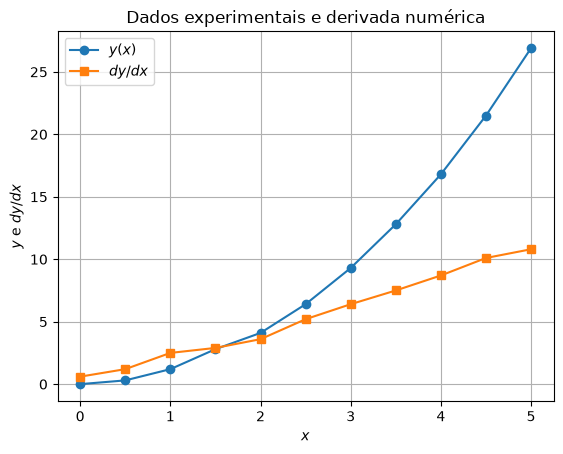

In [8]:
import numpy as np                                      # Importa a biblioteca numérica
import matplotlib.pyplot as plt                         # Importa a biblioteca gráfica

x = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])                # Define os valores de x
y = np.array([0, 0.3, 1.2, 2.8, 4.1, 6.4, 9.3, 12.8, 16.8, 21.5, 26.9])  # Define os valores de y

dydx = np.zeros(len(x))                                # Cria o vetor das derivadas
dydx[0] = (y[1] - y[0]) / (x[1] - x[0])                # Calcula a diferença progressiva
dydx[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])           # Calcula a diferença regressiva
for i in range(1, len(x)-1):
    dydx[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])    # Calcula as diferenças centrais
i_max = np.argmax(dydx)                                # Localiza a maior derivada

print(f"{'x':>6} {'y':>8} {'dy/dx':>10}")              # Exibe o cabeçalho
for i in range(len(x)): 
    print(f"{x[i]:6.1f} {y[i]:8.2f} {dydx[i]:10.4f}") # Exibe os resultados
print(f"\nMaior taxa de variação: x = {x[i_max]:.1f}, dy/dx = {dydx[i_max]:.4f}")  # Exibe o ponto de maior variação

plt.plot(x, y, 'o-', label='$y(x)$')                   # Traça os dados experimentais
plt.plot(x, dydx, 's-', label='$dy/dx$')               # Traça as derivadas
plt.xlabel('$x$')                                      # Define o eixo horizontal
plt.ylabel('$y$ e $dy/dx$')                            # Define o eixo vertical
plt.title('Dados experimentais e derivada numérica')   # Define o título
plt.grid(True)                                         # Adiciona a grade
plt.legend()                                           # Exibe a legenda
plt.show()                                              # Exibe o gráfico

## Exercício 6 — Diferenciação numérica de dados de sensor

Considere os vetores de tempo $t$ e temperatura $T$, sem assumir uma função analítica.

Nos pontos internos, utiliza-se a diferença central:

$$
\frac{dT}{dt}\approx\frac{T_{i+1}-T_{i-1}}{t_{i+1}-t_{i-1}}
$$

No primeiro ponto, utiliza-se a diferença progressiva:

$$
\frac{dT}{dt}\approx\frac{T_1-T_0}{t_1-t_0}
$$

No último ponto, utiliza-se a diferença regressiva:

$$
\frac{dT}{dt}\approx\frac{T_n-T_{n-1}}{t_n-t_{n-1}}
$$

A maior taxa de variação corresponde ao maior valor de $\frac{dT}{dt}$.

Nos pontos internos, a diferença central é preferível porque utiliza informações dos dois lados do ponto. Nos extremos, não há dados em ambos os lados; por isso, utilizam-se diferenças progressiva ou regressiva.

   t (s)     T (°C)     dT/dt (°C/s)
     0.0       25.0           0.5500
     2.0       26.1           0.7500
     4.0       28.0           1.2750
     6.0       31.2           1.7750
     8.0       35.1           2.0750
    10.0       39.5           1.5250
    12.0       41.2           0.6250
    14.0       42.0           0.3250
    16.0       42.5           0.2000
    18.0       42.8           0.1000
    20.0       42.9           0.0500

Maior taxa: t = 8.0 s, dT/dt = 2.0750 °C/s


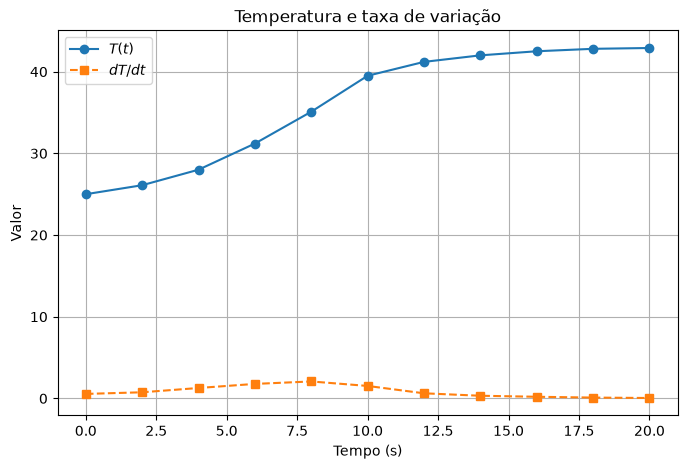

In [15]:
import numpy as np                                      # Importa a biblioteca numérica
import matplotlib.pyplot as plt                        # Importa a biblioteca gráfica
t = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])  # Define os instantes de medição
T = np.array([25.0, 26.1, 28.0, 31.2, 35.1, 39.5, 41.2, 42, 42.5, 42.8, 42.9])  # Define as temperaturas
dTdt = np.zeros(len(t))                                # Cria o vetor das taxas de variação
dTdt[0] = (T[1] - T[0]) / (t[1] - t[0])               # Calcula a diferença progressiva
dTdt[-1] = (T[-1] - T[-2]) / (t[-1] - t[-2])          # Calcula a diferença regressiva
for i in range(1, len(t)-1):
    dTdt[i] = (T[i+1] - T[i-1]) / (t[i+1] - t[i-1])  # Calcula diferenças centrais
i_max = np.argmax(dTdt)                                # Localiza a maior taxa de variação
print(f"{'t (s)':>8} {'T (°C)':>10} {'dT/dt (°C/s)':>16}")  # Exibe o cabeçalho
for i in range(len(t)):
    print(f"{t[i]:8.1f} {T[i]:10.1f} {dTdt[i]:16.4f}")  # Exibe os resultados
print(f"\nMaior taxa: t = {t[i_max]:.1f} s, dT/dt = {dTdt[i_max]:.4f} °C/s")  # Exibe a maior taxa

plt.figure(figsize=(8, 5))                             # Cria a figura
plt.plot(t, T, 'o-', label='$T(t)$')                   # Plota a temperatura
plt.plot(t, dTdt, 's--', label='$dT/dt$')              # Plota a taxa de variação
plt.xlabel('Tempo (s)')                                # Define o eixo horizontal
plt.ylabel('Valor')                                    # Define o eixo vertical
plt.title('Temperatura e taxa de variação')            # Define o título
plt.grid(True)                                         # Adiciona a grade
plt.legend()                                           # Exibe a legenda
plt.show()                                             # Exibe o gráfico

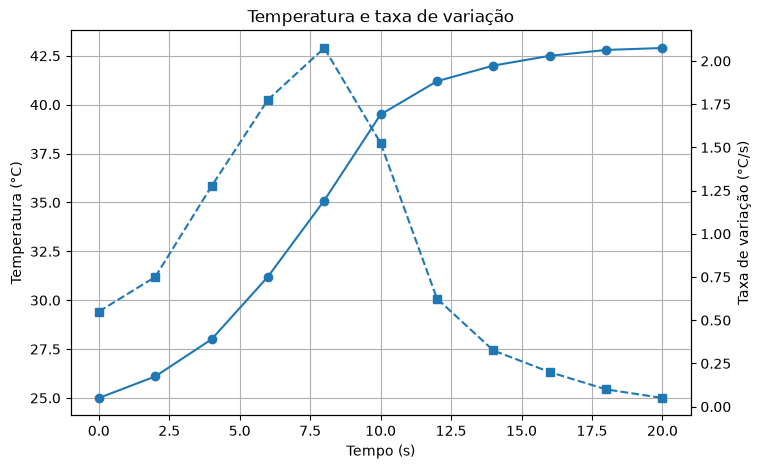

In [17]:
# Gráfico com 2 eixos verticais

fig, ax1 = plt.subplots(figsize=(8, 5))              # Cria a figura e o primeiro eixo
ax1.plot(t, T, 'o-', label='$T(t)$')                 # Traça a temperatura
ax1.set_xlabel('Tempo (s)')                          # Define o eixo horizontal
ax1.set_ylabel('Temperatura (°C)')                   # Define o primeiro eixo vertical
ax1.grid(True)                                       # Adiciona a grade

ax2 = ax1.twinx()                                    # Cria um segundo eixo vertical
ax2.plot(t, dTdt, 's--', label='$dT/dt$')            # Traça a taxa de variação
ax2.set_ylabel('Taxa de variação (°C/s)')            # Define o segundo eixo vertical

plt.title('Temperatura e taxa de variação')          # Define o título
plt.show()                                           # Exibe o gráfico

# Bloco 02 de exercícios

## Exercício 1 — Primeira derivada pela diferença progressiva

Considere a função

$$
f(x)=x^3+2x^2-x
$$

e calcule numericamente a primeira derivada em $x=2$, utilizando a diferença progressiva:

$$
f'(x_i)\approx
\frac{f(x_i+h)-f(x_i)}{h},
$$

com

$$
h=0{,}1.
$$

A função deve ser avaliada nos pontos $x_i$ e $x_i+h$. O resultado numérico deve ser comparado com o valor exato da derivada.

A derivada analítica é

$$
f'(x)=3x^2+4x-1.
$$

Portanto, em $x=2$:

$$
f'(2)=3(2)^2+4(2)-1=19.
$$

O erro absoluto é calculado por

$$
E_a=
\left|f'_{\mathrm{exato}}-f'_{\mathrm{numérico}}\right|.
$$

In [18]:
import numpy as np                                      # Importa a biblioteca numérica

def f(x):                                               # Define a função f(x)
    return x**3 + 2*x**2 - x                            # Retorna o valor da função

def derivada_progressiva(f, x, h):                     # Define a função da diferença progressiva
    return (f(x + h) - f(x)) / h                        # Calcula a primeira derivada progressiva

x = 2.0                                                 # Define o ponto onde a derivada será calculada
h = 0.1                                                 # Define o passo numérico

derivada_numerica = derivada_progressiva(f, x, h)       # Calcula a derivada numericamente
derivada_exata = 3*x**2 + 4*x - 1                      # Calcula o valor exato da derivada
erro_absoluto = abs(derivada_exata - derivada_numerica) # Calcula o erro absoluto

print(f"x = {x:.1f}")                                   # Exibe o ponto de avaliação
print(f"h = {h:.1f}")                                   # Exibe o passo utilizado
print(f"Derivada numérica = {derivada_numerica:.6f}")    # Exibe a derivada numérica
print(f"Derivada exata    = {derivada_exata:.6f}")       # Exibe a derivada exata
print(f"Erro absoluto     = {erro_absoluto:.6f}")        # Exibe o erro absoluto

x = 2.0
h = 0.1
Derivada numérica = 19.810000
Derivada exata    = 19.000000
Erro absoluto     = 0.810000


## Exercício 2 — Primeira derivada pela diferença central

Considere a função

$$
f(x)=\sin(x)
$$

e calcule numericamente a primeira derivada em

$$
x=\frac{\pi}{4},
$$

utilizando a diferença central:

$$
f'(x_i)\approx
\frac{f(x_i+h)-f(x_i-h)}{2h},
$$

com

$$
h=0{,}1.
$$

A diferença central utiliza informações dos dois lados do ponto $x_i$, sendo geralmente mais precisa que a diferença progressiva para o mesmo valor de $h$.

A derivada analítica da função é

$$
f'(x)=\cos(x).
$$

Assim,

$$
f'\left(\frac{\pi}{4}\right)
= \cos\left(\frac{\pi}{4}\right)
= \frac{\sqrt{2}}{2}.
$$

O erro absoluto é calculado por

$$
E_a=
\left|
f'_{\mathrm{exato}}-
f'_{\mathrm{numérico}}
\right|.
$$

In [19]:
import numpy as np                                      # Importa a biblioteca numérica

def f(x):                                               # Define a função f(x)
    return np.sin(x)                                    # Retorna o seno de x

def derivada_central(f, x, h):                          # Define a função da diferença central
    return (f(x + h) - f(x - h)) / (2*h)                # Calcula a primeira derivada central

x = np.pi / 4                                           # Define o ponto de avaliação
h = 0.1                                                 # Define o passo numérico

derivada_numerica = derivada_central(f, x, h)            # Calcula a derivada numericamente
derivada_exata = np.cos(x)                              # Calcula o valor exato da derivada
erro_absoluto = abs(derivada_exata - derivada_numerica) # Calcula o erro absoluto

print(f"x = π/4 = {x:.6f}")                             # Exibe o ponto de avaliação
print(f"h = {h:.1f}")                                   # Exibe o passo utilizado
print(f"Derivada numérica = {derivada_numerica:.6f}")    # Exibe a derivada numérica
print(f"Derivada exata    = {derivada_exata:.6f}")       # Exibe a derivada exata
print(f"Erro absoluto     = {erro_absoluto:.6f}")        # Exibe o erro absoluto

x = π/4 = 0.785398
h = 0.1
Derivada numérica = 0.705929
Derivada exata    = 0.707107
Erro absoluto     = 0.001178


## Exercício 3 — Segunda derivada pela diferença central

Considere a função

$$
f(x)=e^x
$$

e calcule numericamente a segunda derivada em $x=1$, utilizando a fórmula de diferença central:

$$
f''(x_i)\approx
\frac{f(x_i-h)-2f(x_i)+f(x_i+h)}
{h^2},
$$

com

$$
h=0{,}1.
$$

A fórmula utiliza três pontos: $x_i-h$, $x_i$ e $x_i+h$.

Para a função exponencial,

$$
f'(x)=e^x
$$

e

$$
f''(x)=e^x.
$$

Portanto, o valor exato em $x=1$ é

$$
f''(1)=e.
$$

O erro absoluto é calculado por

$$
E_a=
\left|
f''_{\mathrm{exato}}-
f''_{\mathrm{numérico}}
\right|.
$$

In [20]:
import numpy as np                                      # Importa a biblioteca numérica

def f(x):                                               # Define a função f(x)
    return np.exp(x)                                    # Retorna o valor de e^x

def segunda_derivada_central(f, x, h):                  # Define a função da segunda derivada
    return (f(x - h) - 2*f(x) + f(x + h)) / h**2        # Calcula a segunda derivada central

x = 1.0                                                 # Define o ponto de avaliação
h = 0.1                                                 # Define o passo numérico

derivada_numerica = segunda_derivada_central(f, x, h)   # Calcula a segunda derivada numericamente
derivada_exata = np.exp(x)                              # Calcula o valor exato da segunda derivada
erro_absoluto = abs(derivada_exata - derivada_numerica) # Calcula o erro absoluto

print(f"x = {x:.1f}")                                   # Exibe o ponto de avaliação
print(f"h = {h:.1f}")                                   # Exibe o passo utilizado
print(f"Segunda derivada numérica = {derivada_numerica:.6f}") # Exibe o resultado numérico
print(f"Segunda derivada exata    = {derivada_exata:.6f}")    # Exibe o resultado exato
print(f"Erro absoluto             = {erro_absoluto:.6f}")     # Exibe o erro absoluto

x = 1.0
h = 0.1
Segunda derivada numérica = 2.720548
Segunda derivada exata    = 2.718282
Erro absoluto             = 0.002266


## Exercício 4 — Terceira derivada pela diferença progressiva

Considere a função

$$
f(x)=x^4
$$

e calcule numericamente a terceira derivada em $x=1$, utilizando a fórmula de diferença progressiva:

$$
f'''(x_i)\approx
\frac{
-f(x_i)+3f(x_i+h)-3f(x_i+2h)+f(x_i+3h)
}
{h^3},
$$

com

$$
h=0{,}1.
$$

A fórmula utiliza quatro pontos consecutivos:

$$
x_i,\quad x_i+h,\quad x_i+2h,\quad x_i+3h.
$$

A terceira derivada exata da função é

$$
f'''(x)=24x.
$$

Portanto,

$$
f'''(1)=24.
$$

O erro absoluto é calculado por

$$
E_a=
\left|
f'''_{\mathrm{exato}}-
f'''_{\mathrm{numérico}}
\right|.
$$

In [21]:
import numpy as np                                      # Importa a biblioteca numérica

def f(x):                                               # Define a função f(x)
    return x**4                                         # Retorna o valor de x^4

def terceira_derivada_progressiva(f, x, h):             # Define a função da terceira derivada
    return (-f(x) + 3*f(x+h) - 3*f(x+2*h) + f(x+3*h)) / h**3  # Calcula a terceira derivada

x = 1.0                                                 # Define o ponto de avaliação
h = 0.1                                                 # Define o passo numérico

derivada_numerica = terceira_derivada_progressiva(f, x, h) # Calcula a derivada numericamente
derivada_exata = 24*x                                   # Calcula o valor exato da terceira derivada
erro_absoluto = abs(derivada_exata - derivada_numerica) # Calcula o erro absoluto

print(f"x = {x:.1f}")                                   # Exibe o ponto de avaliação
print(f"h = {h:.1f}")                                   # Exibe o passo utilizado
print(f"Terceira derivada numérica = {derivada_numerica:.6f}") # Exibe o resultado numérico
print(f"Terceira derivada exata    = {derivada_exata:.6f}")    # Exibe o resultado exato
print(f"Erro absoluto              = {erro_absoluto:.6f}")     # Exibe o erro absoluto

x = 1.0
h = 0.1
Terceira derivada numérica = 27.600000
Terceira derivada exata    = 24.000000
Erro absoluto              = 3.600000


## Exercício 5 — Comparação do erro para diferentes valores de $h$

Considere a função

$$
f(x)=x^3
$$

e calcule a primeira derivada em $x=3$ utilizando a fórmula progressiva de três pontos:

$$
f'(x_i)\approx
\frac{-3f(x_i)+4f(x_i+h)-f(x_i+2h)}
{2h}.
$$

Calcule a derivada para os seguintes valores do passo:

$$
h=1,\quad
0{,}5,\quad
0{,}25,\quad
0{,}125.
$$

A derivada exata da função é

$$
f'(x)=3x^2.
$$

Assim,

$$
f'(3)=3(3)^2=27.
$$

Para cada valor de $h$, deve-se calcular o erro absoluto:

$$
E_a=
\left|
f'_{\mathrm{exato}}-
f'_{\mathrm{numérico}}
\right|.
$$

Ao reduzir o valor de $h$, espera-se que o resultado numérico se aproxime do valor exato.

Os resultados devem ser apresentados em uma tabela contendo o valor de $h$, a derivada numérica, a derivada exata e o erro absoluto.

In [22]:
import numpy as np                                      # Importa a biblioteca numérica

def f(x):                                               # Define a função f(x)
    return x**3                                         # Retorna o valor de x^3

def derivada_progressiva_3_pontos(f, x, h):             # Define a fórmula progressiva de três pontos
    return (-3*f(x) + 4*f(x+h) - f(x+2*h)) / (2*h)      # Calcula a primeira derivada

x = 3.0                                                 # Define o ponto de avaliação
derivada_exata = 3*x**2                                 # Calcula o valor exato da derivada

h_valores = [1, 0.5, 0.25, 0.125]                      # Define os valores do passo

print(f"{'h':>10} {'Derivada':>15} {'Exata':>15} {'Erro absoluto':>18}") # Exibe o cabeçalho

for h in h_valores:                                     # Percorre todos os valores de h
    derivada_numerica = derivada_progressiva_3_pontos(f, x, h) # Calcula a derivada numérica
    erro_absoluto = abs(derivada_exata - derivada_numerica)     # Calcula o erro absoluto
    
    print(f"{h:10.3f} {derivada_numerica:15.6f} {derivada_exata:15.6f} {erro_absoluto:18.6f}") # Exibe os resultados

         h        Derivada           Exata      Erro absoluto
     1.000       25.000000       27.000000           2.000000
     0.500       26.500000       27.000000           0.500000
     0.250       26.875000       27.000000           0.125000
     0.125       26.968750       27.000000           0.031250
